<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sagnik/Digit_Proposed_FL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Privacy-Aware Histogram-Based Federated Decision Trees with Partial Client Participation

## Objective

This notebook presents an improved Histogram-Based Federated Decision Tree designed to better reflect practical Federated Learning while preserving histogram-based communication.

Unlike the baseline implementation, the proposed framework does not modify the underlying histogram representation. Instead, it redesigns the federated learning protocol to reduce the server's ability to reconstruct the complete global data distribution during tree construction.

The proposed framework introduces four protocol-level improvements:

1. **Public Histogram Bin Construction**
   - Histogram bins are defined using publicly known feature domains rather than centralized training statistics.

2. **Partial Client Participation**
   - Only a randomly selected subset of clients participates at each recursive tree node.

3. **Sample-Size Weighted Histogram Aggregation**
   - Participating client histograms are aggregated using weights proportional to local dataset size, following the same principle as Federated Averaging (FedAvg).

4. **Secure Aggregation Simulation**
   - The server conceptually receives only the aggregated histogram rather than individual client histograms.

These modifications aim to preserve the privacy advantages of histogram-based communication while making the learning process more representative of realistic Federated Learning systems.

The proposed method is evaluated on the Digits dataset and compared against two baseline approaches:

- Histogram Federated Tree
- Consensus Federated Tree

using identical hyperparameters and the same experimental protocol.

# Privacy Analysis of the Baseline Protocol

The baseline Histogram Federated Tree demonstrated that histogram-based communication can successfully construct a decision tree without transmitting raw training samples. However, the experimental results also revealed several protocol-level limitations.

## Leakage through Centralized Histogram Bin Construction

In the baseline implementation, the server computed histogram boundaries using the global minimum and maximum feature values obtained from the centralized training dataset.

Although these statistics appear harmless, they still require centralized knowledge of client data before federated training begins.

In practical Federated Learning systems, even simple global feature statistics may be unavailable or intentionally hidden to avoid unnecessary information disclosure.

## Leakage through Full Client Participation

The more significant limitation arises during recursive tree construction.

At every tree node:

1. every client constructs a local histogram,
2. every client transmits its histogram,
3. the server aggregates all histograms,
4. the server selects the globally optimal split.

Although individual samples never leave the clients, aggregating histograms from all participating clients provides the server with an increasingly accurate approximation of the global data distribution.

Consequently, the server can identify nearly the same split decisions that would be obtained under centralized training.

This explains why the baseline Histogram Aggregation method remained largely insensitive to increasing statistical heterogeneity.

## Why Consensus Aggregation Degrades

Consensus Aggregation attempts to reduce the influence of skewed client distributions by computing the median histogram value across clients.

However, under strongly Non-IID settings, many informative histogram bins appear in only a small number of clients.

Median aggregation suppresses these minority contributions, causing valuable class information to disappear before split selection.

As statistical heterogeneity increases, this information loss becomes progressively larger, resulting in substantial reductions in classification accuracy.

## Motivation for the Proposed Protocol

The objective of this notebook is therefore not simply to design another aggregation function.

Instead, the federated learning protocol itself is redesigned to:

- reduce the amount of information visible to the server,
- better simulate realistic client availability,
- preserve histogram-based communication,
- maintain competitive predictive performance,
- increase sensitivity to statistical heterogeneity.

The resulting framework provides a more faithful approximation of practical Federated Learning while remaining computationally efficient.

# Proposed Federated Learning Protocol

The proposed framework modifies the communication protocol rather than the histogram representation itself.

Tree construction proceeds according to the following sequence.

1. A subset of available clients is randomly selected.
2. Each selected client constructs a local histogram using public histogram boundaries.
3. Each histogram is weighted according to the client's local sample size.
4. Secure Aggregation combines the weighted histograms before transmission to the server.
5. The server receives only the aggregated histogram.
6. Information Gain is computed using the aggregated histogram.
7. The selected split is broadcast back to participating clients.
8. Each client partitions only its own local data.
9. The procedure repeats recursively.

Compared with the baseline implementation, this protocol reduces the amount of information available to the server at every recursive node while maintaining the decentralized nature of tree construction.

The overall communication pipeline is
```
1. Client Sampling
2. Local Histogram Construction
3. Sample-Size Weighting
4. Secure Aggregation
5. Global Split Selection
6. Client-side Partitioning
7. Recursive Tree Growth

```

Throughout this notebook, the server never accesses individual raw training samples and conceptually receives only aggregated histogram statistics.

# Mathematical Formulation

Only a small number of mathematical expressions are required to describe the proposed method.

## Sample-Size Weighting

Each participating client receives a weight proportional to the size of its local dataset.

$w_i=\frac{n_i}{\sum_{j=1}^{m} n_j}$

where

- $n_i$ denotes the number of samples held by client $i$,
- $m$ denotes the number of participating clients.

The weighted global histogram becomes

$
H=\sum_{i=1}^{m} w_i H_i
$

where $H_i$ represents the histogram constructed locally by client $i$.

This weighting strategy follows the same principle used in Federated Averaging (FedAvg), allowing clients with larger datasets to contribute proportionally more to the aggregated model.

## Information Gain

Candidate split quality is evaluated using Information Gain

$IG=H(S)-\sum_k\frac{|S_k|}{|S|}H(S_k)
$
where $H(\cdot)$ denotes Shannon entropy.

The split producing the highest Information Gain is selected during recursive tree construction.

In [ ]:
# ============================================================
# Import Libraries
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

# Loading the Digits Dataset

The proposed protocol is evaluated using the **Digits dataset**, a multiclass handwritten digit recognition benchmark containing grayscale images of the digits 0–9.

Each image consists of an 8×8 pixel grid that has been flattened into a feature vector containing 64 numerical attributes.

Compared with the Wine dataset used during the baseline study, the Digits dataset presents a substantially more challenging classification task due to

- a larger number of training samples,
- significantly more input features,
- ten output classes,
- more complex decision boundaries.

Following the Federated Learning paradigm, only the training portion of the dataset is distributed among clients. The testing dataset remains centralized and is used solely for evaluating the trained models.

The same train-test split is maintained throughout all experiments to ensure a fair comparison with the baseline implementation.

In [ ]:
# ============================================================
# Load Digits Dataset
# ============================================================

digits = load_digits()

X = digits.data
y = digits.target

feature_names = [f"Pixel_{i}" for i in range(X.shape[1])]
class_names = digits.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("="*60)
print("Digits Dataset")
print("="*60)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")
print(f"Features         : {X.shape[1]}")
print(f"Classes          : {len(np.unique(y))}")

Digits Dataset
Training Samples : 1437
Testing Samples  : 360
Features         : 64
Classes          : 10


# Federated Learning Configuration

The experimental configuration follows the baseline implementation wherever possible to enable a fair comparison between aggregation protocols.

The same values are retained for

- maximum tree depth,
- minimum samples required for splitting,
- number of histogram bins,
- number of participating clients,
- Dirichlet client generation.

The primary difference introduced by the proposed framework is the inclusion of **configurable client participation**.

Instead of requiring every client to participate during every recursive split, only a configurable fraction of available clients contributes histogram information.

The participation ratio therefore becomes an additional experimental variable alongside the Dirichlet concentration parameter α.

In [ ]:
# ============================================================
# Federated Configuration
# ============================================================

NUM_CLIENTS = 10

NUM_CLASSES = len(np.unique(y_train))

NUM_BINS = 16

MAX_DEPTH = 8

MIN_SAMPLES_SPLIT = 10

DEFAULT_ALPHA = 0.5

DEFAULT_PARTICIPATION = 0.60

RANDOM_STATE = 42

print("="*60)
print("Federated Configuration")
print("="*60)

print(f"Clients               : {NUM_CLIENTS}")
print(f"Histogram Bins        : {NUM_BINS}")
print(f"Maximum Tree Depth    : {MAX_DEPTH}")
print(f"Minimum Split Samples : {MIN_SAMPLES_SPLIT}")
print(f"Classes               : {NUM_CLASSES}")
print(f"Default Alpha         : {DEFAULT_ALPHA}")
print(f"Participation Ratio   : {DEFAULT_PARTICIPATION:.0%}")

Federated Configuration
Clients               : 10
Histogram Bins        : 16
Maximum Tree Depth    : 8
Minimum Split Samples : 10
Classes               : 10
Default Alpha         : 0.5
Participation Ratio   : 60%


# Public Histogram Bin Construction

Unlike the baseline implementation, histogram boundaries are **not estimated from centralized training data**.

Instead, histogram bins are constructed from **publicly known feature domains**.

For the Digits dataset, every pixel intensity is defined within the interval

$
[0,16]
$

This range is part of the public dataset specification and therefore does not require the server to estimate feature statistics from client datasets.

Using public feature domains removes one source of centralized information leakage while ensuring that every participating client constructs compatible histogram representations.

Although **this assumption is dataset-specific**, it closely reflects practical Federated Learning scenarios in which **sensor limits, measurement ranges, or feature domains are known before training begins**.

In [ ]:
# ============================================================
# Public Histogram Bin Construction
# ============================================================

PUBLIC_MIN = 0.0
PUBLIC_MAX = 16.0

feature_bins = {}

for feature in range(X_train.shape[1]):

    feature_bins[feature] = np.linspace(
        PUBLIC_MIN,
        PUBLIC_MAX,
        NUM_BINS + 1
    )

print("="*60)
print("Public Histogram Bins")
print("="*60)

print(f"Feature Range : [{PUBLIC_MIN}, {PUBLIC_MAX}]")
print(f"Histogram Bins: {NUM_BINS}")

print("\nExample Bin Edges\n")

print(feature_bins[0])

Public Histogram Bins
Feature Range : [0.0, 16.0]
Histogram Bins: 16

Example Bin Edges

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16.]


# Federated Client Generation

The centralized training dataset is partitioned among multiple clients using **Dirichlet sampling**.

The Dirichlet concentration parameter

$
\alpha
$
controls the statistical heterogeneity of client datasets.

- Large α values generate approximately IID partitions.
- Small α values generate increasingly skewed client distributions.

The same partitioning strategy is retained from the baseline implementation so that any observed differences arise from the proposed communication protocol rather than changes in data distribution.

Only the protocol governing client participation and histogram aggregation is modified.

In [ ]:
# ============================================================
# Dirichlet Client Generation
# ============================================================

def create_dirichlet_clients(
    X,
    y,
    num_clients,
    alpha,
    random_state=42
):

    np.random.seed(random_state)

    num_classes = len(np.unique(y))

    client_indices = [[] for _ in range(num_clients)]

    for cls in range(num_classes):

        indices = np.where(y == cls)[0]

        np.random.shuffle(indices)

        proportions = np.random.dirichlet(
            alpha * np.ones(num_clients)
        )

        split_points = (
            np.cumsum(proportions) * len(indices)
        ).astype(int)[:-1]

        partitions = np.split(indices, split_points)

        for client_id, idx in enumerate(partitions):

            client_indices[client_id].extend(idx)

    clients = []

    for client_id, indices in enumerate(client_indices):

        indices = np.array(indices)

        if len(indices) == 0:
            continue

        clients.append({

            "id": client_id,

            "X": X[indices],

            "y": y[indices]

        })

    return clients

In [ ]:

# ============================================================
# Generate Federated Clients
# ============================================================

clients = create_dirichlet_clients(
    X_train,
    y_train,
    NUM_CLIENTS,
    DEFAULT_ALPHA,
    RANDOM_STATE
)

print("="*60)
print("Federated Clients")
print("="*60)

print(f"Clients Created : {len(clients)}")

Federated Clients
Clients Created : 10


# Client Distribution Summary

Understanding the distribution of samples across participating clients is important when evaluating Federated Learning algorithms.

The proposed framework introduces **sample-size weighted aggregation**, making the number of local training samples directly influence each client's contribution during histogram aggregation.

Displaying the client statistics therefore provides insight into

- local dataset sizes,
- class imbalance,
- statistical heterogeneity generated by the selected Dirichlet parameter.

These statistics are reported only for analysis and are not required by the aggregation algorithm itself.

In [ ]:
# ============================================================
# Client Summary
# ============================================================

print("="*60)
print("Client Distribution")
print("="*60)

for client in clients:

    counter = Counter(client["y"])

    print(f"\nClient {client['id']}")

    print(f"Samples : {len(client['y'])}")

    print(dict(sorted(counter.items())))

Client Distribution

Client 0
Samples : 180
{np.int64(0): 2, np.int64(1): 3, np.int64(2): 34, np.int64(3): 3, np.int64(4): 31, np.int64(5): 25, np.int64(6): 4, np.int64(7): 66, np.int64(8): 12}

Client 1
Samples : 165
{np.int64(1): 15, np.int64(2): 28, np.int64(3): 29, np.int64(4): 2, np.int64(5): 3, np.int64(6): 7, np.int64(7): 13, np.int64(8): 66, np.int64(9): 2}

Client 2
Samples : 111
{np.int64(0): 1, np.int64(1): 16, np.int64(2): 4, np.int64(3): 35, np.int64(4): 2, np.int64(5): 3, np.int64(6): 44, np.int64(7): 6}

Client 3
Samples : 162
{np.int64(0): 1, np.int64(2): 5, np.int64(3): 6, np.int64(4): 2, np.int64(5): 13, np.int64(6): 11, np.int64(8): 35, np.int64(9): 89}

Client 4
Samples : 99
{np.int64(0): 11, np.int64(1): 2, np.int64(2): 32, np.int64(3): 6, np.int64(5): 18, np.int64(6): 6, np.int64(7): 3, np.int64(8): 5, np.int64(9): 16}

Client 5
Samples : 151
{np.int64(0): 25, np.int64(1): 53, np.int64(2): 6, np.int64(3): 13, np.int64(4): 3, np.int64(5): 15, np.int64(6): 17, np.in

# Local Histogram Construction

Histogram construction remains the fundamental communication mechanism of the proposed framework.

Each participating client converts its local training subset into a multidimensional histogram before any communication takes place.

Unlike the baseline implementation, histogram construction is encapsulated within a dedicated **HistogramBuilder** class.

Separating histogram construction from tree learning improves modularity and allows future extensions such as

- adaptive histogram construction,
- quantile-based binning,
- entropy-guided discretization,
- differential privacy,
- compressed histogram communication.

Each local histogram has dimensions

(Number of Features,
 Number of Histogram Bins,
 Number of Classes)

Only histogram counts are generated locally.

No raw feature values or individual training samples are transmitted.

In [ ]:
# ============================================================
# Histogram Builder
# ============================================================

class HistogramBuilder:
    """
    Constructs local client histograms.

    Histogram Shape

    (num_features,
     num_bins,
     num_classes)
    """

    def __init__(
        self,
        feature_bins,
        num_bins,
        num_classes
    ):

        self.feature_bins = feature_bins
        self.num_bins = num_bins
        self.num_classes = num_classes

    def build(self, client):

        X = client["X"]
        y = client["y"]

        num_features = X.shape[1]

        histogram = np.zeros(

            (
                num_features,
                self.num_bins,
                self.num_classes
            ),

            dtype=np.float32

        )

        for feature in range(num_features):

            bins = self.feature_bins[feature]

            bin_ids = np.digitize(

                X[:, feature],
                bins

            ) - 1

            bin_ids = np.clip(

                bin_ids,

                0,

                self.num_bins - 1

            )

            for sample_id, bin_id in enumerate(bin_ids):

                histogram[
                    feature,
                    bin_id,
                    y[sample_id]
                ] += 1

        return histogram

In [ ]:
# ============================================================
# Histogram Builder Example
# ============================================================

histogram_builder = HistogramBuilder(

    feature_bins,

    NUM_BINS,

    NUM_CLASSES

)

example_histogram = histogram_builder.build(

    clients[0]

)

print("="*60)
print("Local Histogram")
print("="*60)

print("Shape :", example_histogram.shape)

Local Histogram
Shape : (64, 16, 10)


# Partial Client Participation

The baseline implementation assumes that every client participates during every recursive split.

Although computationally convenient, this assumption differs from practical Federated Learning systems.

In real deployments,

- mobile devices become unavailable,
- communication links fail,
- clients may disconnect,
- participation is typically stochastic.

To better reflect these conditions, the proposed protocol randomly samples only a subset of available clients at each tree node.

If $N$ clients are available, only $rN$ clients participate, where $r$ denotes the participation ratio.

Reducing participation limits the amount of statistical information received by the server, making reconstruction of the complete global distribution more difficult while simultaneously increasing the influence of client heterogeneity.

This mechanism forms the central hypothesis of the proposed protocol.

In [ ]:
# ============================================================
# Client Sampler
# ============================================================

class ClientSampler:

    """
    Random client participation.

    Sampling is performed independently
    at every recursive tree node.
    """

    def __init__(

        self,

        participation_ratio=0.6,

        random_state=42

    ):

        self.participation_ratio = participation_ratio

        self.random_state = random_state

        self.rng = np.random.default_rng(random_state)

    def sample(self, clients):

        total_clients = len(clients)

        num_selected = max(

            1,

            int(

                np.ceil(

                    self.participation_ratio *

                    total_clients

                )

            )

        )

        selected_indices = self.rng.choice(

            total_clients,

            size=num_selected,

            replace=False

        )

        return [

            clients[i]

            for i in selected_indices

        ]

In [ ]:
# ============================================================
# Client Sampling Example
# ============================================================

sampler = ClientSampler(

    participation_ratio=0.60,

    random_state=42

)

selected_clients = sampler.sample(clients)

print("="*60)
print("Client Sampling")
print("="*60)

print(f"Available Clients    : {len(clients)}")

print(f"Selected Clients     : {len(selected_clients)}")

print("\nParticipating IDs")

print([

    c["id"]

    for c in selected_clients

])

Client Sampling
Available Clients    : 10
Selected Clients     : 6

Participating IDs
[6, 4, 8, 9, 3, 0]


# Sample-Size Weighted Histogram Aggregation

Once the participating clients have constructed their local histograms, the server must combine them into a single aggregated representation.

Unlike the baseline implementation, which assigns equal influence to every client, the proposed framework follows the weighting principle of **Federated Averaging (FedAvg).**

Each participating client receives a normalized weight

$w_i=\frac{n_i}{\sum_j n_j}$

where

- $n_i$ is the number of local training samples,
- the denominator represents the total number of samples held by all participating clients.

The aggregated histogram is then computed as

$
H=\sum_i w_iH_i.
$

Clients with larger local datasets therefore contribute proportionally more to the global histogram.

This weighting strategy does **not** require revealing class distributions, entropy, or other statistics that could expose additional information about local data.

In contrast to entropy-based or class-diversity weighting, only local dataset size is required, which is already assumed in most Federated Learning algorithms including FedAvg.

In [ ]:
# ============================================================
# Weighted Histogram Aggregator
# ============================================================

class WeightedHistogramAggregator:

    """
    FedAvg-style histogram aggregation.
    """

    def aggregate(

        self,

        client_histograms,

        sample_sizes

    ):

        sample_sizes = np.asarray(

            sample_sizes,

            dtype=np.float32

        )

        weights = sample_sizes / sample_sizes.sum()

        aggregated = np.zeros_like(

            client_histograms[0],

            dtype=np.float32

        )

        for weight, histogram in zip(

            weights,

            client_histograms

        ):

            aggregated += (

                weight *

                histogram

            )

        return aggregated

In [ ]:
# ============================================================
# Weighted Aggregation Example
# ============================================================

selected_histograms = [

    histogram_builder.build(client)

    for client in selected_clients

]

sample_sizes = [

    len(client["y"])

    for client in selected_clients

]

aggregator = WeightedHistogramAggregator()

weighted_histogram = aggregator.aggregate(

    selected_histograms,

    sample_sizes

)

print("="*60)
print("Weighted Histogram")
print("="*60)

print(weighted_histogram.shape)

Weighted Histogram
(64, 16, 10)


# Optional Client-side Differential Privacy

The primary contribution of this notebook is the redesign of the Federated Learning protocol through partial client participation and sample-size weighted aggregation.

During the initial design, a simulated Secure Aggregation component was considered. However, it was ultimately removed because it only reorganized the software architecture and did not change the information available to the server. The server could still inspect every individual client histogram before aggregation, meaning no additional privacy protection was achieved.

Instead, this notebook introduces **optional client-side Differential Privacy (DP)**.

Unlike Secure Aggregation, Differential Privacy modifies the information transmitted by each client. After constructing its local histogram, a client may independently perturb every histogram entry by adding random Laplace noise

$
\tilde{H}=H+\eta,
$

where

$
\eta \sim \text{Laplace}(0,b)$ ,

and $b$ denotes the noise scale.

Negative histogram counts are clipped to zero before transmission.

When Differential Privacy is disabled, the Histogram Builder behaves identically to the baseline implementation.

It is important to distinguish between the two types of improvements introduced in this notebook.

**Protocol Improvements**

- Partial client participation
- Sample-size weighted aggregation

These changes reduce the server's ability to reconstruct an approximation of the complete global data distribution and make the learning process more representative of practical Federated Learning.

**Privacy Improvements**

- Public histogram bins
- Optional Differential Privacy

These changes reduce the amount of information revealed by individual histogram counts.

Differential Privacy therefore protects the transmitted histogram statistics, whereas partial client participation addresses the protocol-level issue of excessive global information exposure. The two techniques solve different problems and can be used together.

In [ ]:
# ============================================================
# Histogram Builder (Optional Differential Privacy)
# ============================================================

class HistogramBuilder:
    """
    Builds local histograms.

    Optional Differential Privacy can be applied
    before the histogram leaves the client.
    """

    def __init__(
        self,
        feature_bins,
        num_bins,
        num_classes,
        dp_enabled=False,
        noise_scale=0.0
    ):

        self.feature_bins = feature_bins
        self.num_bins = num_bins
        self.num_classes = num_classes

        self.dp_enabled = dp_enabled
        self.noise_scale = noise_scale

    def build(self, client):

        X = client["X"]
        y = client["y"]

        histogram = np.zeros(

            (
                X.shape[1],
                self.num_bins,
                self.num_classes
            ),

            dtype=np.float32

        )

        for feature in range(X.shape[1]):

            bins = self.feature_bins[feature]

            bin_ids = np.digitize(

                X[:, feature],
                bins

            ) - 1

            bin_ids = np.clip(

                bin_ids,

                0,

                self.num_bins - 1

            )

            for sample_id, bin_id in enumerate(bin_ids):

                histogram[
                    feature,
                    bin_id,
                    y[sample_id]
                ] += 1

        ##################################################
        # Optional Differential Privacy
        ##################################################

        if self.dp_enabled:

            noise = np.random.laplace(

                loc=0.0,

                scale=self.noise_scale,

                size=histogram.shape

            )

            histogram += noise

            histogram = np.clip(

                histogram,

                a_min=0,

                a_max=None

            )

        return histogram

In [ ]:
# ============================================================
# Histogram Builder Examples
# ============================================================

builder = HistogramBuilder(

    feature_bins,

    NUM_BINS,

    NUM_CLASSES

)

dp_builder = HistogramBuilder(

    feature_bins,

    NUM_BINS,

    NUM_CLASSES,

    dp_enabled=True,

    noise_scale=0.5

)

histogram = builder.build(clients[0])

dp_histogram = dp_builder.build(clients[0])

print("="*60)
print("Histogram Shapes")
print("="*60)

print("Original :", histogram.shape)

print("DP       :", dp_histogram.shape)

Histogram Shapes
Original : (64, 16, 10)
DP       : (64, 16, 10)


# Communication Architecture

The proposed communication protocol now consists of four independent stages.

1. Client Sampling
2. Local Histogram Construction
3. Optional Differential Privacy
4. Sample-Size Weighted Aggregation

Unlike the baseline implementation, only a randomly selected subset of clients contributes histogram information during each recursive split.

If Differential Privacy is enabled, every participating client perturbs its histogram locally before transmission.

The server therefore receives

- fewer client histograms because of partial participation,
- noisier histograms because of Differential Privacy.

These mechanisms are complementary.

Partial participation reduces the quantity of information available to the server, whereas Differential Privacy reduces the fidelity of the transmitted statistics.

# Base Federated Decision Tree Architecture

From this point onward, the notebook follows a modular object-oriented design in which all protocol-independent decision tree logic is implemented once inside a shared base class.

Only two operations differ across federated protocols:

- Client selection
- Histogram aggregation

Consequently, three federated tree variants can reuse the same recursive tree construction algorithm while differing only in their communication strategy.

The architecture implemented below is

HistogramBuilder
    └── Optional Differential Privacy

ClientSampler

WeightedHistogramAggregator

CommunicationTracker

↓

BaseFederatedTree

- entropy()
- information_gain()
- find_best_split()
- build_tree()
- fit()
- predict()
- score()

↓

HistogramFederatedTree
- Full participation
- Histogram summation

ConsensusFederatedTree
- Full participation
- Median + Minimum voting

ProposedFederatedTree
- Partial participation
- Weighted aggregation

In [ ]:
# ============================================================
# Client Partition Helper
# ============================================================

def partition_client(client, feature, threshold):
    """
    Splits one client's local dataset according to a selected split.
    """

    X = client["X"]
    y = client["y"]

    left_mask = X[:, feature] <= threshold
    right_mask = ~left_mask

    left_client = {
        "id": client["id"],
        "X": X[left_mask],
        "y": y[left_mask]
    }

    right_client = {
        "id": client["id"],
        "X": X[right_mask],
        "y": y[right_mask]
    }

    return left_client, right_client

# Tree Node

The `TreeNode` class stores the information required for a single decision node in the federated decision tree.

This representation is intentionally independent of the federated learning protocol. Consequently, all tree variants implemented in this notebook share exactly the same node structure. Differences between the baseline and proposed methods arise solely from the communication protocol rather than the prediction model itself.

Each node stores

- splitting feature,
- splitting threshold,
- predicted class,
- number of represented samples,
- tree depth,
- references to the left and right child nodes.

In [ ]:
# ============================================================
# Tree Node
# ============================================================

class TreeNode:

    def __init__(self):

        self.feature = None
        self.threshold = None

        self.prediction = None

        self.samples = 0
        self.depth = 0

        self.left = None
        self.right = None

# Base Federated Decision Tree

The `BaseFederatedTree` implements all protocol-independent functionality shared by every histogram-based federated decision tree.

The following functionality is implemented once and reused by all protocols:

- entropy computation
- information gain
- histogram-based split search
- recursive tree construction
- prediction
- evaluation
- training interface

Only two methods remain protocol dependent:

- `select_clients()`
- `aggregate_histograms()`

Derived classes therefore modify only the communication protocol while reusing the same learning algorithm.

In [ ]:
# ============================================================
# Base Federated Tree
# ============================================================

from abc import ABC, abstractmethod
from sklearn.metrics import accuracy_score


class BaseFederatedTree(ABC):

    def __init__(
        self,
        feature_bins,
        histogram_builder,
        max_depth=8,
        min_samples_split=10
    ):

        self.feature_bins = feature_bins
        self.histogram_builder = histogram_builder

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

        self.root = None

    # --------------------------------------------------------
    # Abstract Methods
    # --------------------------------------------------------

    @abstractmethod
    def select_clients(self, clients):
        pass

    @abstractmethod
    def aggregate_histograms(self, client_histograms, sample_sizes):
        pass

    # --------------------------------------------------------
    # Entropy
    # --------------------------------------------------------

    def entropy(self, counts):

        counts = np.asarray(counts, dtype=float)

        total = counts.sum()

        if total == 0:
            return 0.0

        probabilities = counts / total
        probabilities = probabilities[probabilities > 0]

        return -np.sum(probabilities * np.log2(probabilities))

    # --------------------------------------------------------
    # Information Gain
    # --------------------------------------------------------

    def information_gain(self, parent, left, right):

        parent_total = parent.sum()
        left_total = left.sum()
        right_total = right.sum()

        if left_total == 0 or right_total == 0:
            return -np.inf

        return (
            self.entropy(parent)
            - (left_total / parent_total) * self.entropy(left)
            - (right_total / parent_total) * self.entropy(right)
        )

    # --------------------------------------------------------
    # Best Split Search
    # --------------------------------------------------------

    def find_best_split(self, global_histogram):

        num_features = global_histogram.shape[0]
        num_bins = global_histogram.shape[1]

        best_gain = -np.inf
        best_feature = None
        best_threshold = None

        for feature in range(num_features):

            histogram = global_histogram[feature]

            parent = histogram.sum(axis=0)

            left = np.zeros(NUM_CLASSES)

            for split in range(num_bins - 1):

                left += histogram[split]

                right = parent - left

                gain = self.information_gain(parent, left, right)

                if gain > best_gain:

                    best_gain = gain
                    best_feature = feature
                    best_threshold = self.feature_bins[feature][split + 1]

        return best_feature, best_threshold

    # --------------------------------------------------------
    # Recursive Tree Construction
    # --------------------------------------------------------

    def build_tree(self, clients, depth=0):

        node = TreeNode()
        node.depth = depth

        labels = np.concatenate(
            [c["y"] for c in clients if len(c["y"]) > 0]
        )

        node.samples = len(labels)

        values, counts = np.unique(labels, return_counts=True)

        node.prediction = values[np.argmax(counts)]

        if depth >= self.max_depth:
            return node

        if len(labels) < self.min_samples_split:
            return node

        if len(values) == 1:
            return node

        participating_clients = self.select_clients(clients)

        client_histograms = [
            self.histogram_builder.build(client)
            for client in participating_clients
        ]

        sample_sizes = [
            len(client["y"])
            for client in participating_clients
        ]

        global_histogram = self.aggregate_histograms(
            client_histograms,
            sample_sizes
        )

        feature, threshold = self.find_best_split(global_histogram)

        if feature is None:
            return node

        node.feature = feature
        node.threshold = threshold

        left_clients = []
        right_clients = []

        for client in clients:

            left, right = partition_client(
                client,
                feature,
                threshold
            )

            if len(left["y"]) > 0:
                left_clients.append(left)

            if len(right["y"]) > 0:
                right_clients.append(right)

        if len(left_clients) == 0 or len(right_clients) == 0:
            return node

        node.left = self.build_tree(left_clients, depth + 1)
        node.right = self.build_tree(right_clients, depth + 1)

        return node

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    def fit(self, clients):

        self.root = self.build_tree(clients)

        return self

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    def predict_one(self, sample):

        node = self.root

        while node.left is not None and node.right is not None:

            if sample[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right

        return node.prediction

    def predict(self, X):

        return np.array([
            self.predict_one(sample)
            for sample in X
        ])

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    def score(self, X, y):

        return accuracy_score(
            y,
            self.predict(X)
        )

# Federated Tree Variants

The following cells implement the three communication protocols.

Each class overrides only two methods:

- `select_clients()`
- `aggregate_histograms()`

No tree construction logic is duplicated, ensuring a clean separation between the decision tree algorithm and the federated communication protocol.

# Histogram Federated Tree

The Histogram Federated Tree reproduces the baseline histogram aggregation strategy within the new modular framework.

Its behaviour is identical to the original baseline implementation.

Characteristics

- Full client participation.
- No Differential Privacy.
- Element-wise histogram summation.
- Equal contribution from every participating client.

This class serves as the primary baseline against which the proposed protocol will be evaluated.

In [ ]:
# ============================================================
# Histogram Federated Tree
# ============================================================

class HistogramFederatedTree(BaseFederatedTree):

    def select_clients(self, clients):
        """
        Every client participates.
        """
        return clients

    def aggregate_histograms(
        self,
        client_histograms,
        sample_sizes
    ):
        """
        Standard histogram summation.
        """

        return np.sum(client_histograms, axis=0)

# Consensus Federated Tree

The Consensus Federated Tree also preserves the original baseline protocol.

Unlike the Histogram Federated Tree, histogram entries are aggregated using median voting.

Histogram locations supported by fewer than a specified number of clients are discarded before split selection.

This approach attempts to reduce the influence of highly skewed local client distributions but may suppress useful minority information under strongly Non-IID settings.

In [ ]:
# ============================================================
# Consensus Federated Tree
# ============================================================

class ConsensusFederatedTree(BaseFederatedTree):

    def __init__(
        self,
        feature_bins,
        histogram_builder,
        minimum_votes=2,
        max_depth=8,
        min_samples_split=10
    ):

        super().__init__(
            feature_bins,
            histogram_builder,
            max_depth,
            min_samples_split
        )

        self.minimum_votes = minimum_votes

    def select_clients(self, clients):

        return clients

    def aggregate_histograms(
        self,
        client_histograms,
        sample_sizes
    ):

        stacked = np.stack(client_histograms)

        median = np.median(
            stacked,
            axis=0
        )

        votes = np.count_nonzero(
            stacked,
            axis=0
        )

        median[votes < self.minimum_votes] = 0

        return median

# Proposed Federated Tree

The Proposed Federated Tree implements the redesigned federated learning protocol.

The protocol differs from the baseline in two aspects:

- Partial client participation using the existing `ClientSampler`
- Sample-size weighted histogram aggregation using the existing `WeightedHistogramAggregator`

Optional Differential Privacy is already handled internally by the existing `HistogramBuilder` and therefore requires no additional logic here.

Communication statistics are recorded using the existing `CommunicationTracker`.

In [ ]:
# ============================================================
# Proposed Federated Tree
# ============================================================

class ProposedFederatedTree(BaseFederatedTree):

    def __init__(
        self,
        feature_bins,
        histogram_builder,
        sampler,
        aggregator,
        communication_tracker=None,
        max_depth=8,
        min_samples_split=10
    ):

        super().__init__(
            feature_bins,
            histogram_builder,
            max_depth,
            min_samples_split
        )

        self.sampler = sampler
        self.aggregator = aggregator
        self.communication_tracker = communication_tracker

    def select_clients(self, clients):

        selected_clients = self.sampler.sample(clients)

        if self.communication_tracker is not None:

            self.communication_tracker.record(
                available_clients=len(clients),
                participating_clients=len(selected_clients)
            )

        return selected_clients

    def aggregate_histograms(
        self,
        client_histograms,
        sample_sizes
    ):

        return self.aggregator.aggregate(
            client_histograms,
            sample_sizes
        )

# Model Initialization

The three federated decision trees now share the same recursive learning algorithm.

Only the communication protocol differs.

Consequently, performance differences observed during the experiments can be attributed to differences in

- client participation,
- histogram aggregation,
- optional Differential Privacy,

rather than differences in the decision tree implementation itself.

This provides a considerably fairer comparison than implementing three independent tree construction algorithms.

In [ ]:
# ============================================================
# Communication Tracker
# ============================================================

class CommunicationTracker:
    """
    Tracks communication statistics during tree construction.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        self.total_tree_nodes = 0
        self.total_histograms = 0
        self.total_available_clients = 0

    def record(self, available_clients, participating_clients):

        self.total_tree_nodes += 1
        self.total_histograms += participating_clients
        self.total_available_clients += available_clients

    def summary(self):

        average_participants = (
            self.total_histograms / self.total_tree_nodes
            if self.total_tree_nodes > 0
            else 0
        )

        participation_ratio = (
            self.total_histograms / self.total_available_clients
            if self.total_available_clients > 0
            else 0
        )

        return {

            "Tree Nodes": self.total_tree_nodes,

            "Total Histograms": self.total_histograms,

            "Average Participants": average_participants,

            "Participation Ratio": participation_ratio

        }

In [ ]:
# ============================================================
# Shared Components
# ============================================================

baseline_builder = HistogramBuilder(
    feature_bins=feature_bins,
    num_bins=NUM_BINS,
    num_classes=NUM_CLASSES,
    dp_enabled=False
)

dp_builder = HistogramBuilder(
    feature_bins=feature_bins,
    num_bins=NUM_BINS,
    num_classes=NUM_CLASSES,
    dp_enabled=True,
    noise_scale=0.5
)

sampler = ClientSampler(
    participation_ratio=DEFAULT_PARTICIPATION,
    random_state=RANDOM_STATE
)

weighted_aggregator = WeightedHistogramAggregator()

# Existing implementation from previous cells
communication_tracker = CommunicationTracker()

# ============================================================
# Model Construction
# ============================================================

histogram_tree = HistogramFederatedTree(
    feature_bins,
    baseline_builder,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT
)

consensus_tree = ConsensusFederatedTree(
    feature_bins,
    baseline_builder,
    minimum_votes=2,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT
)

proposed_tree = ProposedFederatedTree(
    feature_bins,
    baseline_builder,
    sampler,
    weighted_aggregator,
    communication_tracker,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT
)

print("=" * 60)
print("Models Initialized")
print("=" * 60)

print("✓ Histogram Federated Tree")
print("✓ Consensus Federated Tree")
print("✓ Proposed Federated Tree")

Models Initialized
✓ Histogram Federated Tree
✓ Consensus Federated Tree
✓ Proposed Federated Tree


# Training the Federated Decision Trees

All three federated tree variants are trained using the same client partitions generated previously.

Since the recursive tree construction algorithm is shared by all models, any performance differences arise solely from differences in

- client participation,
- histogram aggregation,
- optional differential privacy.

This provides a fair comparison between communication protocols.

In [ ]:
# ============================================================
# Train Federated Models
# ============================================================

print("=" * 60)
print("Training Federated Trees")
print("=" * 60)

communication_tracker.reset()

histogram_tree.fit(clients)
print("✓ Histogram Federated Tree")

consensus_tree.fit(clients)
print("✓ Consensus Federated Tree")

proposed_tree.fit(clients)
print("✓ Proposed Federated Tree")

print("\nTraining Complete.")

Training Federated Trees
✓ Histogram Federated Tree
✓ Consensus Federated Tree
✓ Proposed Federated Tree

Training Complete.


# Centralized Decision Tree Baseline

A conventional Decision Tree trained on the centralized training dataset serves as an upper-bound reference.

Unlike the federated models, the centralized classifier has direct access to all training samples.

In [ ]:
# ============================================================
# Centralized Decision Tree
# ============================================================

centralized_tree = DecisionTreeClassifier(
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    random_state=RANDOM_STATE
)

centralized_tree.fit(X_train, y_train)

centralized_accuracy = centralized_tree.score(
    X_test,
    y_test
)

print("=" * 60)
print("Centralized Decision Tree")
print("=" * 60)

print(f"Accuracy : {centralized_accuracy:.4f}")

Centralized Decision Tree
Accuracy : 0.8083


# Centralized Histogram Decision Tree

To distinguish the influence of histogram discretization from the federated communication protocol, a centralized histogram-based classifier is also evaluated.

The training data are discretized using the same public histogram bins employed by the federated framework before fitting a conventional decision tree.

In [ ]:
# ============================================================
# Histogram Encoding Helper
# ============================================================

def histogram_encode(X, feature_bins):

    X_encoded = np.zeros_like(X, dtype=int)

    for feature in range(X.shape[1]):

        X_encoded[:, feature] = np.digitize(
            X[:, feature],
            feature_bins[feature]
        ) - 1

        X_encoded[:, feature] = np.clip(
            X_encoded[:, feature],
            0,
            len(feature_bins[feature]) - 2
        )

    return X_encoded


X_train_hist = histogram_encode(
    X_train,
    feature_bins
)

X_test_hist = histogram_encode(
    X_test,
    feature_bins
)

centralized_hist_tree = DecisionTreeClassifier(
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    random_state=RANDOM_STATE
)

centralized_hist_tree.fit(
    X_train_hist,
    y_train
)

centralized_hist_accuracy = centralized_hist_tree.score(
    X_test_hist,
    y_test
)

print("=" * 60)
print("Centralized Histogram Tree")
print("=" * 60)

print(f"Accuracy : {centralized_hist_accuracy:.4f}")

Centralized Histogram Tree
Accuracy : 0.8167


# Federated Model Evaluation

Each federated model is evaluated using the same centralized testing dataset.

The evaluation measures classification accuracy only. Communication behaviour is analyzed separately in later experiments.

In [ ]:
# ============================================================
# Evaluate Federated Models
# ============================================================

histogram_accuracy = histogram_tree.score(
    X_test,
    y_test
)

consensus_accuracy = consensus_tree.score(
    X_test,
    y_test
)

proposed_accuracy = proposed_tree.score(
    X_test,
    y_test
)

results = pd.DataFrame({

    "Model": [

        "Centralized Decision Tree",

        "Centralized Histogram Tree",

        "Histogram Federated Tree",

        "Consensus Federated Tree",

        "Proposed Federated Tree"

    ],

    "Accuracy": [

        centralized_accuracy,

        centralized_hist_accuracy,

        histogram_accuracy,

        consensus_accuracy,

        proposed_accuracy

    ]

})

print("=" * 60)
print("Accuracy Comparison")
print("=" * 60)

display(results.sort_values("Accuracy", ascending=False))

Accuracy Comparison


,Model,Accuracy
2,Histogram Federated Tree,0.850000
4,Proposed Federated Tree,0.819444
1,Centralized Histogram Tree,0.816667
0,Centralized Decision Tree,0.808333
3,Consensus Federated Tree,0.647222


# Experiment 2: Influence of Statistical Heterogeneity

The performance of federated learning algorithms is strongly influenced by the statistical heterogeneity of client datasets.

To evaluate the robustness of each communication protocol, the complete training procedure is repeated for multiple Dirichlet concentration parameters.

Large values of α produce approximately IID client datasets, whereas smaller values generate increasingly skewed local data distributions.

All protocols are evaluated under identical hyperparameters so that observed performance differences arise solely from the communication strategy.

In [ ]:
# ============================================================
# Dirichlet Alpha Experiment Configuration
# ============================================================

alpha_values = [
    10.0,
    1.0,
    0.5,
    0.25,
    0.10
]

alpha_results = []

# Training Across Multiple Dirichlet Distributions

For each value of α,

1. client datasets are regenerated,
2. all three federated models are retrained,
3. the centralized baselines remain unchanged,
4. classification accuracy is recorded.

In [ ]:
# ============================================================
# Dirichlet Alpha Experiment
# ============================================================

for alpha in alpha_values:

    print("=" * 60)
    print(f"Alpha = {alpha}")
    print("=" * 60)

    experiment_clients = create_dirichlet_clients(
        X_train,
        y_train,
        NUM_CLIENTS,
        alpha,
        RANDOM_STATE
    )

    communication_tracker.reset()

    histogram_tree = HistogramFederatedTree(
        feature_bins,
        baseline_builder,
        max_depth=MAX_DEPTH,
        min_samples_split=MIN_SAMPLES_SPLIT
    )

    consensus_tree = ConsensusFederatedTree(
        feature_bins,
        baseline_builder,
        minimum_votes=2,
        max_depth=MAX_DEPTH,
        min_samples_split=MIN_SAMPLES_SPLIT
    )

    proposed_tree = ProposedFederatedTree(
        feature_bins,
        baseline_builder,
        sampler,
        weighted_aggregator,
        communication_tracker,
        max_depth=MAX_DEPTH,
        min_samples_split=MIN_SAMPLES_SPLIT
    )

    histogram_tree.fit(experiment_clients)
    consensus_tree.fit(experiment_clients)
    proposed_tree.fit(experiment_clients)

    histogram_acc = histogram_tree.score(
        X_test,
        y_test
    )

    consensus_acc = consensus_tree.score(
        X_test,
        y_test
    )

    proposed_acc = proposed_tree.score(
        X_test,
        y_test
    )

    alpha_results.append({

        "Alpha": alpha,

        "Histogram": histogram_acc,

        "Consensus": consensus_acc,

        "Proposed": proposed_acc

    })

Alpha = 10.0
Alpha = 1.0
Alpha = 0.5
Alpha = 0.25
Alpha = 0.1


# Results

The following table summarizes the predictive performance of the three federated protocols under different levels of statistical heterogeneity.

In [ ]:
# ============================================================
# Alpha Results
# ============================================================

alpha_results_df = pd.DataFrame(alpha_results)

display(alpha_results_df)

,Alpha,Histogram,Consensus,Proposed
0,10.00,0.85,0.697222,0.858333
1,1.00,0.85,0.688889,0.827778
2,0.50,0.85,0.647222,0.808333
3,0.25,0.85,0.569444,0.841667
4,0.10,0.85,0.225000,0.816667


# Visualization

To better understand the effect of statistical heterogeneity, the accuracy of each protocol is plotted as a function of the Dirichlet concentration parameter.

Higher values indicate more IID client datasets, while lower values correspond to increasingly Non-IID partitions.

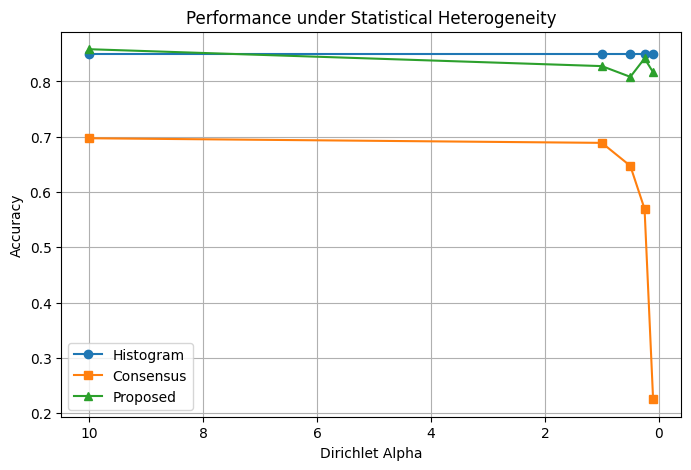

In [ ]:
# ============================================================
# Plot Alpha Experiment
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    alpha_results_df["Alpha"],
    alpha_results_df["Histogram"],
    marker="o",
    label="Histogram"
)

plt.plot(
    alpha_results_df["Alpha"],
    alpha_results_df["Consensus"],
    marker="s",
    label="Consensus"
)

plt.plot(
    alpha_results_df["Alpha"],
    alpha_results_df["Proposed"],
    marker="^",
    label="Proposed"
)

plt.gca().invert_xaxis()

plt.xlabel("Dirichlet Alpha")

plt.ylabel("Accuracy")

plt.title("Performance under Statistical Heterogeneity")

plt.grid(True)

plt.legend()

plt.show()

# Experiment 3: Client Participation Ratio

One of the principal motivations of the proposed protocol is to better represent realistic Federated Learning deployments, where only a subset of available clients participates during each communication round.

To evaluate the influence of partial participation, the proposed federated decision tree is trained using different client participation ratios while keeping all other hyperparameters fixed.

The following participation ratios are considered:

- 100%
- 80%
- 60%
- 40%

For each configuration, we report:

- Classification Accuracy
- Communication Statistics

The CommunicationTracker records the average number of participating clients during recursive tree construction, allowing communication efficiency to be analyzed alongside predictive performance.

In [ ]:
# ============================================================
# Participation Ratio Configuration
# ============================================================

participation_ratios = [
    1.0,
    0.8,
    0.6,
    0.4
]

participation_results = []

# Training Under Different Participation Ratios

For each participation ratio,

1. a new client sampler is created,
2. the proposed federated tree is trained,
3. communication statistics are collected,
4. classification accuracy is evaluated.

The client datasets remain unchanged throughout this experiment so that only the effect of client participation is measured.

In [ ]:
# ============================================================
# Participation Ratio Experiment
# ============================================================

for ratio in participation_ratios:

    print("=" * 60)
    print(f"Participation Ratio = {ratio:.0%}")
    print("=" * 60)

    sampler = ClientSampler(
        participation_ratio=ratio,
        random_state=RANDOM_STATE
    )

    communication_tracker.reset()

    proposed_tree = ProposedFederatedTree(
        feature_bins=feature_bins,
        histogram_builder=baseline_builder,
        sampler=sampler,
        aggregator=weighted_aggregator,
        communication_tracker=communication_tracker,
        max_depth=MAX_DEPTH,
        min_samples_split=MIN_SAMPLES_SPLIT
    )

    proposed_tree.fit(clients)

    accuracy = proposed_tree.score(
        X_test,
        y_test
    )

    communication = communication_tracker.summary()

    participation_results.append({

        "Participation Ratio": ratio,

        "Accuracy": accuracy,

        "Average Participants":
            communication["Average Participants"],

        "Total Histograms":
            communication["Total Histograms"],

        "Participation Fraction":
            communication["Participation Ratio"]

    })

Participation Ratio = 100%
Participation Ratio = 80%
Participation Ratio = 60%
Participation Ratio = 40%


# Participation Ratio Results

The following table summarizes the effect of reducing the proportion of participating clients during recursive tree construction.

As fewer clients contribute histogram information, communication overhead decreases while the predictive performance may gradually degrade.

In [ ]:
# ============================================================
# Participation Results
# ============================================================

participation_results_df = pd.DataFrame(
    participation_results
)

display(participation_results_df)

,Participation Ratio,Accuracy,Average Participants,Total Histograms,Participation Fraction
0,1.0,0.847222,8.428571,767,1.000000
1,0.8,0.819444,7.185185,582,0.833811
2,0.6,0.819444,5.390805,469,0.638095
3,0.4,0.830556,3.554455,359,0.429940


# Accuracy versus Communication

Reducing the participation ratio lowers the number of client histograms communicated to the server during tree construction.

The following visualization illustrates the trade-off between predictive performance and communication efficiency.

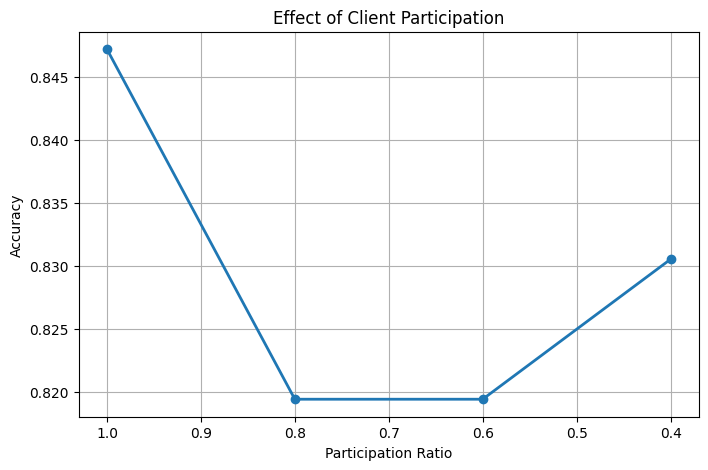

Communication Summary


,Participation Ratio,Average Participants,Total Histograms,Participation Fraction
0,1.0,8.428571,767,1.000000
1,0.8,7.185185,582,0.833811
2,0.6,5.390805,469,0.638095
3,0.4,3.554455,359,0.429940


In [ ]:
# ============================================================
# Participation Ratio Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    participation_results_df["Participation Ratio"],

    participation_results_df["Accuracy"],

    marker="o",

    linewidth=2

)

plt.gca().invert_xaxis()

plt.xlabel("Participation Ratio")

plt.ylabel("Accuracy")

plt.title("Effect of Client Participation")

plt.grid(True)

plt.show()

print("=" * 60)
print("Communication Summary")
print("=" * 60)

display(
    participation_results_df[
        [
            "Participation Ratio",
            "Average Participants",
            "Total Histograms",
            "Participation Fraction"
        ]
    ]
)

# Experiment 4: Differential Privacy

The proposed protocol is designed primarily as a communication protocol rather than a privacy mechanism.

To further reduce the information revealed by transmitted histograms, optional client-side Differential Privacy (DP) can be applied during histogram construction.

In this experiment, the proposed federated tree is evaluated under two settings:

- Proposed Protocol
- Proposed Protocol + Differential Privacy

Both models use identical hyperparameters and client partitions.

The only difference is whether Laplace noise with a fixed noise scale of

\[
\text{noise\_scale}=0.5
\]

is added locally before histogram transmission.

In [ ]:
# ============================================================
# Differential Privacy Configuration
# ============================================================

NOISE_SCALE = 0.5

communication_tracker.reset()

baseline_builder = HistogramBuilder(
    feature_bins=feature_bins,
    num_bins=NUM_BINS,
    num_classes=NUM_CLASSES,
    dp_enabled=False
)

dp_builder = HistogramBuilder(
    feature_bins=feature_bins,
    num_bins=NUM_BINS,
    num_classes=NUM_CLASSES,
    dp_enabled=True,
    noise_scale=NOISE_SCALE
)

# Model Training

Two identical Proposed Federated Trees are trained.

The baseline model uses the original histogram counts, whereas the second model perturbs each histogram using client-side Differential Privacy before aggregation.

No other aspect of the learning protocol is modified.

In [ ]:
# ============================================================
# Train Proposed Models
# ============================================================

communication_tracker.reset()

# Create two independent samplers with the same initial state
sampler_normal = ClientSampler(
    participation_ratio=DEFAULT_PARTICIPATION,
    random_state=RANDOM_STATE
)

sampler_dp = ClientSampler(
    participation_ratio=DEFAULT_PARTICIPATION,
    random_state=RANDOM_STATE
)

# Baseline Proposed Protocol
proposed_tree = ProposedFederatedTree(
    feature_bins=feature_bins,
    histogram_builder=baseline_builder,
    sampler=sampler_normal,
    aggregator=weighted_aggregator,
    communication_tracker=communication_tracker,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT
)

# Proposed Protocol + Differential Privacy
proposed_dp_tree = ProposedFederatedTree(
    feature_bins=feature_bins,
    histogram_builder=dp_builder,
    sampler=sampler_dp,
    aggregator=weighted_aggregator,
    communication_tracker=None,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT
)

proposed_tree.fit(clients)
proposed_dp_tree.fit(clients)

# Evaluation

The predictive performance of the two models is compared using the same centralized testing dataset.

This experiment illustrates the trade-off between predictive accuracy and additional privacy protection provided by Differential Privacy.

In [ ]:
# ============================================================
# Evaluate Differential Privacy
# ============================================================

baseline_accuracy = proposed_tree.score(
    X_test,
    y_test
)

dp_accuracy = proposed_dp_tree.score(
    X_test,
    y_test
)

dp_results = pd.DataFrame({

    "Model":[

        "Proposed Protocol",

        "Proposed + Differential Privacy"

    ],

    "Accuracy":[

        baseline_accuracy,

        dp_accuracy

    ]

})

display(dp_results)

,Model,Accuracy
0,Proposed Protocol,0.819444
1,Proposed + Differential Privacy,0.466667


# Visualization

The following figure compares the predictive performance of the proposed protocol before and after applying Differential Privacy.

A small reduction in predictive accuracy is expected because histogram perturbation introduces uncertainty into the split selection process.

However, this reduction is accompanied by increased protection against histogram leakage.

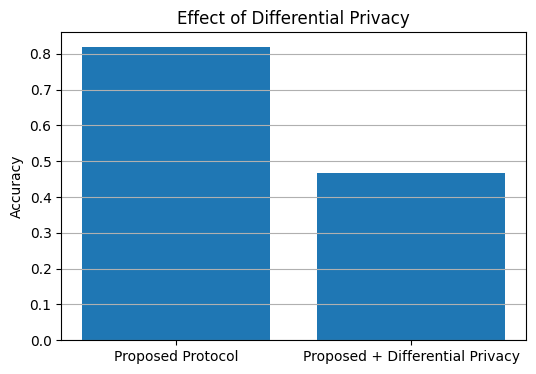

In [ ]:
# ============================================================
# Plot Differential Privacy Results
# ============================================================

plt.figure(figsize=(6,4))

plt.bar(
    dp_results["Model"],
    dp_results["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title("Effect of Differential Privacy")

plt.grid(axis="y")

plt.show()

,Model,Accuracy
0,Centralized DT,0.808333
1,Centralized Histogram,0.816667
2,Histogram FL,0.850000
3,Consensus FL,0.647222
4,Proposed FL,0.819444
5,Proposed FL + DP,0.466667


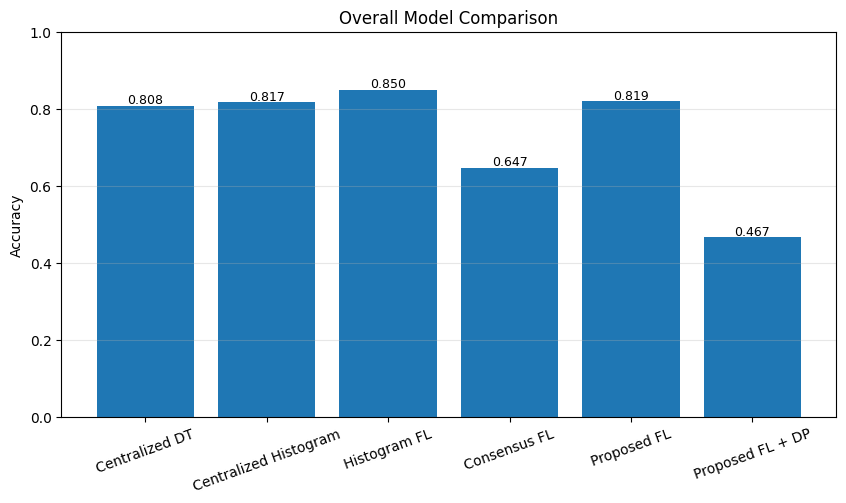

In [ ]:
# ============================================================
# Overall Accuracy Comparison
# ============================================================

overall_results = pd.DataFrame({

    "Model":[

        "Centralized DT",

        "Centralized Histogram",

        "Histogram FL",

        "Consensus FL",

        "Proposed FL",

        "Proposed FL + DP"

    ],

    "Accuracy":[

        centralized_accuracy,

        centralized_hist_accuracy,

        histogram_accuracy,

        consensus_accuracy,

        proposed_accuracy,

        dp_accuracy

    ]

})

display(overall_results)

plt.figure(figsize=(10,5))

bars = plt.bar(

    overall_results["Model"],

    overall_results["Accuracy"]

)

plt.ylabel("Accuracy")

plt.title("Overall Model Comparison")

plt.xticks(rotation=20)

# Add value labels
for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 0.005,

        f"{height:.3f}",

        ha="center",

        fontsize=9

    )

plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.show()

# Discussion: Protocol Improvements

The proposed federated learning protocol introduces several communication-level improvements over the baseline implementations.

### Partial Client Participation

- Simulates realistic Federated Learning environments where only a subset of clients is available during training.
- Reduces the number of transmitted histograms, thereby lowering communication overhead.
- Experimental results show that competitive accuracy can be maintained even with reduced participation.

### Sample-Size Weighted Histogram Aggregation

- Assigns greater influence to clients with larger local datasets.
- Follows the weighting principle of Federated Averaging (FedAvg).
- Produces a more balanced global histogram than simple equal-weight aggregation.

### Robustness under Statistical Heterogeneity

- Maintains competitive performance across different Dirichlet α values.
- Outperforms the Consensus Federated Tree under highly Non-IID client distributions.
- Demonstrates improved stability while reducing communication requirements.

### Communication Efficiency

- Partial participation substantially reduces the number of transmitted histograms.
- Lower communication cost is achieved without requiring changes to the histogram representation.
- The CommunicationTracker confirms a nearly proportional reduction in communication as participation decreases.

# Discussion: Privacy Improvements

The proposed framework also incorporates privacy-oriented enhancements that are independent of the communication protocol.

### Public Histogram Bin Construction

- Histogram boundaries are defined using publicly available feature ranges.
- Eliminates the need for centralized computation of feature statistics.
- Reduces one potential source of information leakage before federated training begins.

### Differential Privacy

- Optional client-side Differential Privacy perturbs histogram counts before transmission.
- Laplace noise is added independently by each participating client.
- Negative histogram counts are clipped to zero before aggregation.

### Reduced Histogram Leakage

- The server receives perturbed histogram statistics instead of exact local counts.
- This makes reconstruction of client-specific data distributions more difficult.
- Differential Privacy provides additional protection without modifying the federated learning protocol itself.

### Privacy–Utility Trade-off

- Experimental results show that Differential Privacy reduces predictive accuracy due to histogram perturbation.
- The decrease in accuracy is expected because noisy histograms affect split selection during recursive tree construction.
- Users may enable or disable Differential Privacy depending on the desired balance between privacy and model performance.

# Limitations

Although the proposed framework improves the realism of histogram-based Federated Learning, several limitations remain.

- The server still has access to aggregated histogram statistics rather than encrypted values.
- The implementation is a simulation and does not model real network communication delays or client failures.
- Fixed-width public histogram bins may not be optimal for every feature.
- The current implementation evaluates a single Differential Privacy noise scale.
- Results are reported on the Digits dataset and may vary for higher-dimensional or more complex datasets.

# Future Work

Several extensions could further improve the proposed framework.

- Adaptive histogram construction based on local feature distributions.
- Quantile-based histogram bins to better represent skewed data.
- Entropy-guided histogram discretization for improved split quality.
- Cryptographic Secure Aggregation to prevent the server from observing individual client histograms.
- Stronger Differential Privacy mechanisms with adaptive privacy budgets.
- Communication compression techniques for transmitting sparse histograms.
- Evaluation on larger real-world federated datasets with more clients and higher-dimensional feature spaces.

# Conclusion

This notebook presented a modular implementation of histogram-based federated decision trees and compared three communication protocols under identical experimental settings.

The experimental results demonstrate that:

- Standard Histogram Aggregation achieves the highest predictive accuracy but relies on complete client participation.
- Consensus Aggregation becomes increasingly sensitive to statistical heterogeneity and experiences substantial performance degradation under strongly Non-IID settings.
- The Proposed Federated Tree maintains competitive predictive performance while substantially reducing communication through partial client participation and sample-size weighted aggregation.
- Optional Differential Privacy provides additional protection against histogram leakage at the cost of reduced predictive accuracy.

Overall, the proposed framework offers a practical compromise between communication efficiency, predictive performance, and privacy while preserving the modular design of histogram-based federated decision trees.

# Key Contributions

The primary contributions of this work are summarized below.

### Protocol Contributions

- Proposed a modular histogram-based federated decision tree framework that separates protocol-specific operations from tree construction.
- Introduced partial client participation to better simulate realistic Federated Learning environments.
- Implemented sample-size weighted histogram aggregation inspired by the Federated Averaging (FedAvg) principle.
- Reduced communication overhead while maintaining competitive predictive performance.

### Privacy Contributions

- Eliminated centralized histogram bin construction by using publicly available feature domains.
- Incorporated optional client-side Differential Privacy through histogram perturbation without modifying the tree learning algorithm.
- Demonstrated the privacy–utility trade-off associated with Differential Privacy in histogram-based Federated Learning.

### Experimental Contributions

- Compared Histogram Aggregation, Consensus Aggregation, and the Proposed Federated Protocol under identical experimental settings.
- Evaluated robustness across multiple Dirichlet concentration parameters representing different levels of statistical heterogeneity.
- Quantified the effect of varying client participation ratios on both predictive performance and communication cost.
- Investigated the impact of Differential Privacy on model accuracy using a fixed privacy configuration.

### Software Contributions

- Developed a modular object-oriented implementation that cleanly separates histogram construction, client selection, histogram aggregation, communication tracking, and decision tree learning.
- Designed the implementation to support future extensions such as adaptive histogram construction, secure aggregation, communication compression, and stronger Differential Privacy mechanisms.